# 1. Тема 1. Моделирование геометрической вероятности

In [1]:
import scipy.special as sc

> Смоделируйте вычисление геометрической вероятности (на примере из лекции про метание дротиков в игровой круг, площадь которого в два раза меньше площади стены). Показать теоретический расчет и графическую иллюстрацию для рассматриваемого примера.

Смоделируем процесс метания дротиков, где в игровой круг вписан правильный шестиугольник.

Рассмотрим событие А - дротик попал во вписанный шестиугольник.

$P(A) = \frac{S_{шестиугольника}}{S_{круга}} = \frac{\frac{3\sqrt3}{2}R^2}{\pi R^2} = \frac{3\sqrt3}{2\pi} = 0,827$

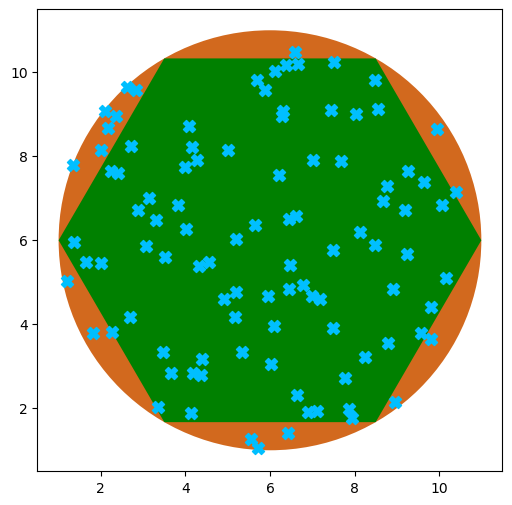

В зелёный шестиугольник из 100 дротиков попало 83. Доля попавших составила: 0.8300


In [224]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, RegularPolygon
import numpy as np

def darts(size):
    x0, y0, R = 6, 6, 5
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.add_patch(Circle((x0, y0), R, facecolor='chocolate'))
    ax.add_patch(RegularPolygon((x0, y0), numVertices=6, radius=R, orientation=np.pi/6, facecolor='green'))
    
    theta = np.random.uniform(0, 2 * np.pi, size)
    r = R * np.sqrt(np.random.rand(size))
    X = x0 + r * np.cos(theta)
    Y = y0 + r * np.sin(theta)
    plt.scatter(X, Y, marker='X', c='deepskyblue', s=75)

    dx, dy = X - x0, Y - y0
    inside = np.sum((np.abs(dx) <= R) & 
        (np.abs(dy) <= R * np.sqrt(3)/2) & 
        (np.abs(dx) + np.abs(dy)/np.sqrt(3) <= R))
    prob = inside / size

    plt.show()
    print(f'В зелёный шестиугольник из {size} дротиков попало {inside}. Доля попавших составила: {prob:.4f}')
darts(100)